<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/title.png' width=500/></center>


# 학습 목표

- MySQL에 연결하여 데이터를 가져올 수 있습니다.

### 1.라이브러리 설치

- MySQL 연결을 위해 pymysql 라이브러리를 설치합니다.

In [1]:
!pip install pymysql 

- 암호화 모듈을 설치한 후 런타임을 재시작합니다.(아나콘다의 경우 설치 불필요)

In [ ]:
# !pip install cryptography

### 2.라이브러리 불러오기

- 사용할 라이브러리를 불러옵니다.

In [3]:
# 라이브러리 불러오기
import pymysql
import pandas as pd
from sqlalchemy import create_engine

### 3.MySQL 연결


- 연결 관련 정보를 지정하여 MySQL에 연결합니다.
- 관련 정보와 권한을 얻기 위해서 서버 관리자의 협조가 필요할 수 있습니다.

In [15]:
# MySQL 연결
user = 'root'
password = 'aivle'
host = '127.0.0.1'
database = 'myshop2024'

connect_string = f'mysql+pymysql://{user}:{password}@{host}/{database}'
mysql = create_engine(connect_string)

### 4.데이터 읽어오기

- 데이터를 조회할 쿼리문을 작성합니다.(쿼리문 학습 필요)
- read_sql 함수를 사용해서 쿼리를 실행해 그 결과를 가져옵니다.
- 가져온 결과는 자동으로 데이터프레임이 됩니다.

**예제1) 조건에 맞는 데이터 가져오기**

In [19]:
# 쿼리문
sql = """
SELECT customer_name, customer_id, IF(gender='M', '남자', '여자') AS gender, 
       phone, city, register_date, point 
    FROM customer
    WHERE point >=500000
    ORDER BY customer_name ASC
"""

# 데이터프레임 만들기
data = pd.read_sql(sql, con=mysql) 

# 확인
data.head()

,customer_name,customer_id,gender,phone,city,register_date,point
0,김대표,chiefkim,남자,010-4621-3864,서울,2021-09-09,800435
1,김양반,ybkim,남자,010-3489-7859,인천,2019-11-30,637150
2,김행복,happykim,여자,010-2883-3560,서울,2022-01-08,500560
3,김호호,hohokim,여자,010-3433-4130,서울,2019-03-15,1556645
4,박마당,mdpark,여자,010-9990-9657,서울,2019-09-30,1653215


**예제2) 집계 결과 가져오기**

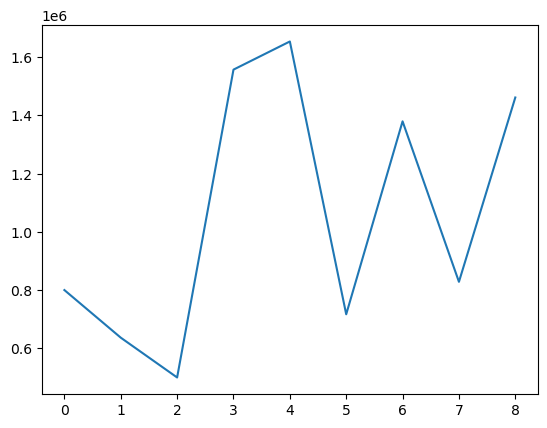

In [22]:
import matplotlib.pyplot as plt

plt.plot(data['point'])
plt.show()

In [24]:
# 쿼리문
sql = """
SELECT city AS 지역, 
       SUM(point) AS 포인트합, 
       GROUP_CONCAT(customer_name ORDER BY customer_name ASC) AS 고객명 
    FROM customer
    WHERE YEAR(register_date) = 2021 AND point > 0
    GROUP BY city
    ORDER BY 포인트합 DESC
"""

# 데이터프레임 만들기
data = pd.read_sql(sql, con=mysql) 

# 확인
data.head(10)

,지역,포인트합,고객명
0,서울,1629155.0,"김대표,한 산"
1,인천,1272625.0,"김청사,오유식,이국가,이등교,이모형,이바다,이위태"
2,부산,1147675.0,"김굴비,남궁최고,이요가,최여신"
3,수원,376230.0,"김감찬,김초록,오대파,최횡재"
4,광주,314800.0,"박진지,양학사,최세기"
5,강릉,160010.0,"박마음,이어른,최 수영"
6,대구,102760.0,"이꿈날,환청자"
7,경주,102620.0,"오사또,이망원,최촌장,함거북"
8,의정부,80345.0,"김모듬,김요리"
9,울산,46840.0,양나리


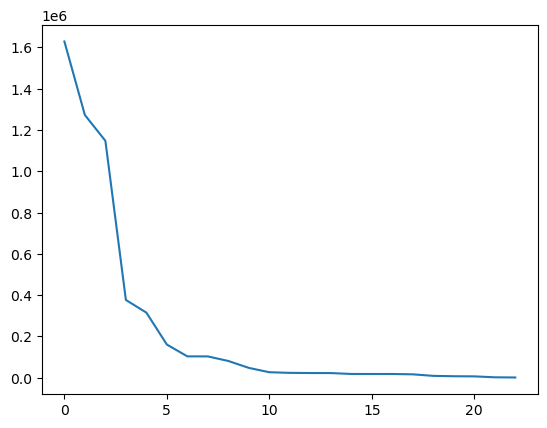

In [26]:
import matplotlib.pyplot as plt

plt.plot(data['포인트합'])
plt.show()

<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/end.png' width=300/></center>